# Kaggle Competition info:
## NVIDIA Nemotron Model Reasoning Challenge
#### Advance reasoning techniques using NVIDIA Nemotron open models on a novel benchmark

## Overview
Develop techniques that improve reasoning accuracy using NVIDIA Nemotron models.

Participants will experiment with prompting, data pipelines, and lightweight fine-tuning while evaluating their approaches on a new reasoning benchmark developed by NVIDIA Research.

**Link:** <https://www.kaggle.com/competitions/nvidia-nemotron-model-reasoning-challenge/overview>

## Install libary

In [1]:
install_DIR= "kaggle/input/datasets/johnsonhk88"
# Install deepeval package
!pip install deepeval  --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/deepeval-4.0.2-py3-none-any.whl
!pip install portalocker --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/portalocker-3.2.0-py3-none-any.whl
!pip install posthog --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/posthog-7.15.0-py3-none-any.whl
!pip install pyfiglet --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/pyfiglet-1.0.4-py3-none-any.whl

# Install Mlflow
!pip install mlflow --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow-3.12.0-py3-none-any.whl
!pip install mlflow_skinny --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow_skinny-3.12.0-py3-none-any.whl
!pip install mlflow_tracing --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow_tracing-3.12.0-py3-none-any.whl
!pip install databricks-sdk --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/databricks_sdk-0.110.0-py3-none-any.whl

# !pip install --no-build-isolation -q "mamba-ssm>=2.2" causal-conv1d
!pip install causal-conv1d  --no-index --no-deps --find-links=file:////kaggle/input/datasets/grooking/mamba-ssm/causal_conv1d-1.6.1-cp312-cp312-linux_x86_64.whl
!pip install mamba-ssm  --no-index --no-deps --find-links=file:////kaggle/input/datasets/grooking/mamba-ssm/mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl

!pip install bitsandbytes --no-index --no-deps --find-links=file:////{install_DIR}/bitsandbytes/bitsandbytes-package/bitsandbytes-0.48.0-py3-none-manylinux_2_24_x86_64.whl
!pip install trl --no-index --no-deps --find-links=file:////{install_DIR}/trl-transformers-reinforcement-learning/trl-package/trl-1.2.0-py3-none-any.whl

Looking in links: file:////kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/deepeval-4.0.2-py3-none-any.whl
Processing //kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/deepeval-4.0.2-py3-none-any.whl
Looking in links: file:////kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/portalocker-3.2.0-py3-none-any.whl
Processing //kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/portalocker-3.2.0-py3-none-any.whl
Looking in links: file:////kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/posthog-7.15.0-py3-none-any.whl
Processing //kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/posthog-7.15.0-py3-none-any.whl
Looking in links: file:////kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/pyfiglet-1.0.4-py3-none-any.whl
Processing //kaggle/input/datasets/johnsonhk88/deepeval-4-0-2/deepeval-package/pyfiglet-1.0.4-py3-none-any.whl
Looking in links: file:////kaggle/input/datasets/j

In [2]:
# !pip install posthog==7.15.0
# !pip install portalocker==3.2.0
# !pip install pyfiglet==1.0.4
# !pip install databricks-sdk==0.110.0

In [3]:
# !pip install -q triton
# !pip install --no-build-isolation -q "mamba-ssm>=2.2" causal-conv1d

In [4]:
import triton
import mamba_ssm
import bitsandbytes

print(triton.__version__)
print(mamba_ssm.__version__)
print(bitsandbytes.__version__)

3.6.0
2.3.1
0.48.0


In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
import deepeval
import mlflow

In [6]:
from deepeval.metrics import GEval                     # ← Only this is needed
from deepeval.test_case import LLMTestCase
from deepeval import evaluate

In [7]:
# from trl import DPOTrainer, DPOConfig
# from peft import PeftModel, LoraConfig
# from datasets import load_dataset
# import torch

import os, glob, sys, subprocess, site, importlib.util, shutil, stat, types, re

import datasets
import kagglehub

import torch
# import mamba_ssm later

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
from trl import GRPOConfig, GRPOTrainer

import pandas as pd
import random
import gc, time

import json, zipfile

In [8]:
import pandas as pd
import torch
import gc
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from typing import Optional, Tuple, Dict


import kagglehub
# import mamba_ssm
# from trl import GRPOConfig, GRPOTrainer

In [9]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

In [10]:
class CFG:
    trainFile = "/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv"
    testFile = "/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/test.csv"

    llmModel1 = "/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1"

In [11]:
mlflow_local= True # suitable for kaggle envirorment
# OUTPUT_DIR = "./model-finetuned"
MLFLOW_EXPERIMENT = "Nemoton-Reasoning-Fine-Tuning"


if mlflow_local:
    mlflowUrl = "sqlite:///mlflow.db" # for local sqlite db (recommend)
    # mlflowUrl = "file:///mlruns" # for local file 

else:
    # localhost
    mlflowUrl = "http://localhost:5000"




def setup_mlflow_run(
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = "",
    train: bool = True
):
    """
    Separate MLflow setup function.
    Sets tracking URI, experiment, starts a run, and returns the active run context.
    """
    # project setup
    mlflow.set_tracking_uri(mlflowUrl)
    mlflow.set_experiment(experiment_name)

    # === CRITICAL: End any previously active run to prevent conflict ===
    try:
        mlflow.end_run()          # safely ends any lingering run
    except:
        pass                      # no active run → ignore
    
    run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run

    if train:
        run_name = f"train_{run_name_suffix}"
    else:
        run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run
        
    


In [12]:
def clearMemory():
    for _ in range(5):
        torch.cuda.empty_cache()
        gc.collect()
        time.sleep(0.3)

In [13]:
clearMemory()

## Load Dataset

In [14]:
# ====================== DATASET LOADING ======================
def load_train_data() -> pd.DataFrame:
    """Load the full training dataset (train.csv)"""
    df = pd.read_csv(CFG.trainFile)
    print(f"✅ Loaded train dataset: {len(df):,} examples")
    return df


def load_val_data(val_size: int = 400) -> pd.DataFrame:
    """Load a fixed validation split from train.csv (same samples every run)"""
    train_df = load_train_data()
    if val_size > len(train_df):
        print(f"⚠️  Requested val_size ({val_size}) > available data. Using all {len(train_df)} samples.")
        val_size = len(train_df)
    val_df = train_df.sample(n=val_size, random_state=42).reset_index(drop=True)
    print(f"✅ Created fixed validation split: {len(val_df)} examples")
    return  train_df , val_df


def load_test_data() -> pd.DataFrame:
    """Load the official test dataset (test.csv) for final inference"""
    df = pd.read_csv(CFG.testFile)
    print(f"✅ Loaded test dataset: {len(df)} examples")
    return df

In [15]:
trainDF, valDF = load_val_data(200)


✅ Loaded train dataset: 9,500 examples
✅ Created fixed validation split: 200 examples


In [16]:
# trainDF
valDF

,id,prompt,answer
0,18c797f1,"In Alice's Wonderland, a secret bit manipulati...",11100111
1,b13d511a,"In Alice's Wonderland, a secret set of transfo...",\&[[
2,71cd0e14,"In Alice's Wonderland, numbers are secretly co...",XXV
3,452b0241,"In Alice's Wonderland, a secret unit conversio...",20.72
4,7a4063e6,"In Alice's Wonderland, a secret bit manipulati...",10010110
...,...,...,...
195,f20e64f5,"In Alice's Wonderland, the gravitational const...",221.54
196,b8738676,"In Alice's Wonderland, secret encryption rules...",wizard sees inside tower
197,233ba645,"In Alice's Wonderland, numbers are secretly co...",XCIX
198,6445da05,"In Alice's Wonderland, a secret unit conversio...",64.35


In [17]:
testDF =  load_test_data()
testDF

✅ Loaded test dataset: 3 examples


,id,prompt
0,00066667,"In Alice's Wonderland, a secret bit manipulati..."
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati..."
2,00189f6a,"In Alice's Wonderland, secret encryption rules..."


In [18]:
print(trainDF["prompt"][0])

In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01010001 -> 11011101
00001001 -> 01101101
00010101 -> 01010101
11111111 -> 10000001
10011101 -> 01000101
00111011 -> 00001001
10111101 -> 00000101
00100110 -> 10110011

Now, determine the output for: 00110100


# Load Model

In [19]:
BASE_MODEL_PATH = kagglehub.model_download("metric/nemotron-3-nano-30b-a3b-bf16/transformers/default")
BASE_MODEL_PATH

'/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1'

In [20]:
def load_model(
    model_name: str,
    adapter_path: Optional[str] = None
) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
    """Load base model + optional LoRA adapter."""
    print(f"Loading model: {model_name} {'+ adapter: ' + adapter_path if adapter_path else '(base)'}")
    
    # === Model + LoRA (Mamba/MoE stable config) ===
    # bnb_config = BitsAndBytesConfig(
    #     load_in_4bit=True,                    # ← Change from 8-bit to 4-bit
    #     bnb_4bit_quant_type="nf4",            # nf4 is best for most models
    #     bnb_4bit_use_double_quant=True,       # Saves extra memory + more stable
    #     bnb_4bit_compute_dtype=torch.bfloat16,  # or torch.float16
    # )
    # === Model + LoRA (8-bit + smaller rank = stable for Mamba) ===
    # bnb_config = BitsAndBytesConfig(
    #     load_in_8bit=True,                    # ← Changed to 8-bit (more stable)
    #     # bnb_4bit_compute_dtype=torch.bfloat16,
    #     bnb_4bit_compute_dtype=torch.float16,
    # )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        # quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        dtype=torch.bfloat16,
        # dtype=torch.float16 # for 8bit
    )

    if adapter_path:
        model = PeftModel.from_pretrained(model, adapter_path)

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

## Load base model

In [21]:

# del model
# del tokenizer

In [22]:
clearMemory()

In [23]:

 model, tokenizer = load_model(BASE_MODEL_PATH, None)

Loading model: /kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1 (base)


Loading weights:   0%|          | 0/6243 [00:00<?, ?it/s]

## Evaluation function

In [41]:
def run_evaluation(
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = ""
) -> Dict:
    run = setup_mlflow_run(experiment_name, run_name_suffix)

    mlflow.log_param("val_size", val_size)
    mlflow.log_param("generation_method", "apply_chat_template + greedy_generate")

    test_cases = []
    exact_matches = []
    start_time = time.time()

    print(f"Running evaluation on {val_size} samples using direct generate...")

    for idx, row in enumerate(valDF.iterrows(), start=1):
        _, row = row  # unpack
        prompt = row['prompt']
        gt = str(row['answer']).strip()

        print(f"Eval Sample: {idx}")
#         full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer.</s>
# <|user|>{prompt}</s>
# <|assistant|>"""

        full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.</s>
<|user|>{prompt}</s>
<|assistant|>"""

        # messages = [
        #     {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
        #     {"role": "user", "content": prompt}
        # ]
        # messages = [
        #     {
        #         "role": "system",
        #         "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. "
        #                    "Analyze the examples carefully, but output ONLY the final answer. "
        #                    "Do NOT explain, do NOT show reasoning, do NOT write 'the answer is', "
        #                    "do NOT add any text before or after the answer. Just output the result."
        #     },
        #     {"role": "user", "content": prompt}
        # ]
        
        # full_prompt = tokenizer.apply_chat_template(
        #     messages,
        #     tokenize=False,
        #     add_generation_prompt=True,
        #     # return_tensors="pt"
        #     # enable_thinking=enable_thinking
        # )
        
        # Tokenize as string → tensor
        tokenized = tokenizer(
            full_prompt,
            return_tensors="pt",
            add_special_tokens=True
        )

        input_ids = tokenized.input_ids.to(model.device)
        input_len = tokenized["input_ids"].shape[-1]
        attention_mask = tokenized.attention_mask.to(model.device)

        # === Generate ===
        outputs = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=256,
            do_sample=False,
            num_beams=1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
        
        # === CLEAN DECODING (new) ===
        generated_tokens = outputs[0][input_len:]
        full_output = tokenizer.decode(generated_tokens, skip_special_tokens=False)
        
        # Extract only assistant response
        if "<|assistant|>" in full_output:
            pred = full_output.split("<|assistant|>")[-1]
        else:
            pred = full_output
        
        # Remove common special tokens
        special_tokens = ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]
        for token in special_tokens:
            pred = pred.replace(token, "").strip()

        # Take the last non-empty line (very effective against CoT)
        lines = [line.strip() for line in pred.split('\n') if line.strip()]
        pred = lines[-1] if lines else pred.strip()
        
        pred = pred.strip()   # final clean
        print(f"Exact ans: {gt.lower().strip()}")
        print(f"Pred ans: { pred.lower().strip()}\n")
        

        is_exact = 1.0 if pred.lower().strip() == gt.lower().strip() else 0.0
        exact_matches.append(is_exact)
        print(f"Matches = {is_exact}")
        print("-"*20)

        test_case = LLMTestCase(input=prompt, actual_output=pred, expected_output=gt)
        test_cases.append(test_case)

        if idx % 5 == 0 or idx == len(valDF):
            print(f"   Processed {idx}  samples...")
        
        if idx>= val_size:
            break
        

    # Metrics
    avg_exact_match = sum(exact_matches) / val_size
    mlflow.log_metric("exact_match", avg_exact_match)
    mlflow.log_metric("eval_time_sec", time.time() - start_time)
    mlflow.log_metric("samples_evaluated", val_size)

    # DeepEval require external LLM implement, but competition not allow access internet 
    # correctness_metric = GEval(
    #     name="Answer Correctness",
    #     criteria="Determine whether the actual output exactly matches the expected output. Be strict.",
    #     evaluation_params=["actual_output", "expected_output"],
    # )
    # rule_quality_metric = GEval(
    #     name="Rule Discovery Quality",
    #     criteria="Does the model correctly discover the hidden transformation rule from the examples and apply it accurately?",
    #     evaluation_params=["actual_output", "expected_output"],
    # )

    # print("Running DeepEval GEval...")
    # results = evaluate(test_cases, [correctness_metric, rule_quality_metric], verbose=False)

    # mlflow.log_metric("deepeval_answer_correctness", results[0].score)
    # mlflow.log_metric("deepeval_rule_quality", results[1].score)

    print(f"\n=== EVALUATION RESULTS ===")
    # print(f"Exact Match (manual):       {avg_exact_match:.4f}")
    # print(f"DeepEval Correctness:       {results[0].score:.4f}")
    # print(f"DeepEval Rule Quality:      {results[1].score:.4f}")
    # print(f"Evaluation time:            {time.time() - start_time:.1f} seconds")
    print(f"\n=== EVALUATION RESULTS (on exactly {len(valDF)} samples) ===")
    print(f"Exact Match Accuracy: {avg_exact_match:.4f} ({int(avg_exact_match*val_size)}/{val_size})")
    mlflow.end_run()

    return {
        # "exact_match": avg_exact_match,
        # "deepeval_correctness": results[0].score,
        # "deepeval_rule_quality": results[1].score,
        "exact_match": avg_exact_match,
        "samples_used": val_size
    }

        
    

In [42]:
def evaluate_model(
    # model_name: str,
    # adapter_path: Optional[str] = None,
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    suffix= "base"
):
    """Convenience wrapper"""
    # model, tokenizer = load_model(model_name, adapter_path)
    # suffix = "base" if adapter_path is None else adapter_path.split("/")[-1]
    return run_evaluation(model, tokenizer, val_size, experiment_name, run_name_suffix=suffix)

## Evaluate base model

In [26]:
evaluate_model(
    # model_name= BASE_MODEL_PATH,
    model,
    tokenizer,
    val_size=10
)

NemotronH requires an initialized `NemotronHHybridDynamicCache` to return a cache. None was provided, so no cache will be returned.


MLflow run started: eval_base (ID: 0033f735d11c40528b9b8123327d314a)
Running evaluation on 10 samples using direct generate...
Eval Sample: 1
Exact ans: 11100111
Pred ans: 10110100

Matches = 0.0
--------------------
Eval Sample: 2
Exact ans: \&[[
Pred ans: 

Matches = 0.0
--------------------
Eval Sample: 3
Exact ans: xxv
Pred ans: xxv

Matches = 1.0
--------------------
Eval Sample: 4
Exact ans: 20.72
Pred ans: 28.55

Matches = 0.0
--------------------
Eval Sample: 5
Exact ans: 10010110
Pred ans: 01001101

Matches = 0.0
--------------------
   Processed 5  samples...
Eval Sample: 6
Exact ans: 00000111
Pred ans: 10111011

Matches = 0.0
--------------------
Eval Sample: 7
Exact ans: {/"
Pred ans: 

Matches = 0.0
--------------------
Eval Sample: 8
Exact ans: lvi
Pred ans: lii

Matches = 0.0
--------------------
Eval Sample: 9
Exact ans: 01000000
Pred ans: 10011111

Matches = 0.0
--------------------
Eval Sample: 10
Exact ans: wizard follows inside wonderland
Pred ans: wizard sees under

{'exact_match': 0.1, 'samples_used': 10}

In [27]:
experiments = mlflow.search_experiments()
for exp in experiments:
    print(f"Experiment ID: {exp.experiment_id}, Name: {exp.name}")

Experiment ID: 1, Name: wonderland_nemotron_reasoning
Experiment ID: 0, Name: Default


In [28]:
# baseEvalRet = mlflow.search_runs(experiment_ids=["1"])
baseEvalRet = mlflow.search_runs(search_all_experiments=True)
baseEvalRet

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.eval_time_sec,metrics.samples_evaluated,metrics.exact_match,params.val_size,...,params.label_smoothing_factor,params.save_total_limit,params.dataloader_prefetch_factor,params.packing_strategy,params.pad_to_multiple_of,params.bf16_full_eval,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.source.type
0,0033f735d11c40528b9b8123327d314a,1,FINISHED,/kaggle/working/mlruns/1/0033f735d11c40528b9b8...,2026-05-31 12:39:00.847000+00:00,2026-05-31 12:39:38.176000+00:00,37.284928,10.0,0.1,10,...,None,None,None,None,None,None,eval_base,root,__notebook_source__.ipynb,NOTEBOOK
1,3b81f71c570d48f09b8157b96e71a6e4,1,FINISHED,/kaggle/working/mlruns/1/3b81f71c570d48f09b815...,2026-05-31 12:34:29.811000+00:00,2026-05-31 12:37:11.515000+00:00,NaN,NaN,NaN,None,...,0.0,1,None,bfd,None,False,eval_sft_training,root,__notebook_source__.ipynb,NOTEBOOK
2,aa4af15d3ade4989b841f51ef1248099,1,FINISHED,/kaggle/working/mlruns/1/aa4af15d3ade4989b841f...,2026-05-31 12:30:39.395000+00:00,2026-05-31 12:31:44.367000+00:00,NaN,NaN,NaN,None,...,0.0,1,None,bfd,None,False,eval_sft_training,root,__notebook_source__.ipynb,NOTEBOOK
3,96aaac6b64c94d65a1cb847f46fa7f26,1,FINISHED,/kaggle/working/mlruns/1/96aaac6b64c94d65a1cb8...,2026-05-31 12:25:59.650000+00:00,2026-05-31 12:28:25.651000+00:00,NaN,NaN,NaN,None,...,0.0,1,None,bfd,None,False,eval_sft_training,root,__notebook_source__.ipynb,NOTEBOOK
4,6f66c20f3d8f480f8219dda748979feb,1,FINISHED,/kaggle/working/mlruns/1/6f66c20f3d8f480f8219d...,2026-05-31 12:23:39.600000+00:00,2026-05-31 12:25:19.231000+00:00,99.591443,10.0,0.1,10,...,None,None,None,None,None,None,eval_base,root,__notebook_source__.ipynb,NOTEBOOK


# Single Test for debug 

In [43]:
# testPrompt = valDF.iloc[0]["prompt"]
# testAns = valDF.iloc[0]["answer"]
# testPrompt

In [44]:

# full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
# You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
# <|user|>{testPrompt}
# <|assistant|>"""
# prompt = full_prompt

In [45]:
# messages = [
#             {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
#             {"role": "user", "content": testPrompt}
#         ]

# prompt = tokenizer.apply_chat_template(
#     messages,
#     tokenize=False,
#     add_generation_prompt=True,
#     # return_tensors="pt"
#     # enable_thinking=enable_thinking
# )
# prompt

In [46]:
# tokenized = tokenizer(
#     prompt,
#     return_tensors="pt",
#     add_special_tokens=True
# )
# input_ids = tokenized.input_ids.to(model.device)
# input_len = tokenized["input_ids"].shape[-1]
# attention_mask = tokenized.attention_mask.to(model.device)

In [47]:

# === Generate ===
# outputs = model.generate(
#     input_ids,
#     attention_mask=attention_mask,
#     max_new_tokens=1024,
#     do_sample=False,
#     num_beams=1,
#     eos_token_id=tokenizer.eos_token_id,
#     pad_token_id=tokenizer.pad_token_id,
# )

In [48]:
# # Decode and extract answer
# === CLEAN DECODING (new) ===
# full_output = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=False)

# # Extract only assistant response
# if "<|assistant|>" in full_output:
#     pred = full_output.split("<|assistant|>")[-1]
# else:
#     pred = full_output

# # Remove common special tokens
# special_tokens = ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]
# for token in special_tokens:
#     pred = pred.replace(token, "").strip()

# pred = pred.strip()   # final clean

In [49]:
# full_output

In [50]:
# pred

###
### Full SFT (Supervised Fine-Tuning) script for NVIDIA Nemotron challenge.
#### Uses real train.csv + modular functions from evaluation.py
###

In [51]:
# OUTPUT_ADAPTER = "/kaggle/working/sft_final"
SFT_ADAPTER = "/kaggle/working/sft_final"
OUTPUT_ADAPTER = "/kaggle/working/grpo_final"

In [52]:
# === NEW TRAINING PROMPT FORMAT (same as your working eval prompt) ===
def format_sft_example(row):
    prompt = row['prompt']
    answer = str(row['answer']).strip()
    
    full_text = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
<|user|>{prompt}
<|assistant|>{answer}"""

    return {"text": full_text}

## LoRA config

In [53]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM")
model = get_peft_model(model, lora_config)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [54]:
model.print_trainable_parameters()

trainable params: 434,659,328 || all params: 32,012,596,672 || trainable%: 1.3578


In [55]:
# lora_config

In [56]:
# === YOUR COMPUTE_METRIC FUNCTION (added here) ===
# def compute_metric(eval_pred):
#     logits, labels = eval_pred
#     # predictions = np.argmax(logits, axis=-1)   # for multi-class
#     top3_preds = np.argsort(logits, axis=-1)[:, -3:]
#     match = (top3_preds == labels[:, None])
#     predictions = top3_preds[:, 2]
#     acc = (predictions == labels).mean()
#     f1score = f1_score(labels, predictions, average='weighted', zero_division=1)
#     recallScore = recall_score(labels, predictions, average='weighted', zero_division=1)
#     precision = precision_score(labels, predictions, average='weighted', zero_division=1)
   
#     # MAP@3
#     map3 = 0
#     for i in range(len(labels)):
#         if match[i, 0]:
#             map3 += 1.0
#         elif match[i, 1]:
#             map3 += 1.0 / 2
#         elif match[i, 2]:
#             map3 += 1.0 / 3
#     map3Score = map3 / len(labels)
   
#     return {
#         "accuracy": acc,
#         "recall": recallScore,
#         "precision": precision,
#         "f1-score": f1score,
#         "map_3": map3Score
#     }

# === FULL METRICS (your request) - computed on last token ===
# === FIXED COMPUTE_METRIC (handles both torch and numpy) ===
# def compute_metric(eval_pred):
#     logits, labels = eval_pred
    
#     # Convert to numpy if they are tensors
#     if isinstance(logits, torch.Tensor):
#         logits = logits.cpu().numpy()
#     if isinstance(labels, torch.Tensor):
#         labels = labels.cpu().numpy()
    
#     # Token-level accuracy (next-token prediction)
#     shift_logits = logits[..., :-1, :]
#     shift_labels = labels[..., 1:]
#     preds = np.argmax(shift_logits, axis=-1)
#     mask = shift_labels != -100
#     token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

#     # Classification metrics on the LAST token only
#     last_logits = logits[:, -1, :]
#     last_labels = labels[:, -1]
#     top3_preds = np.argsort(last_logits, axis=-1)[:, -3:]
#     match = (top3_preds == last_labels[:, None])
#     predictions = top3_preds[:, 2]

#     acc = (predictions == last_labels).mean()
#     f1score = f1_score(last_labels, predictions, average='weighted', zero_division=1)
#     recallScore = recall_score(last_labels, predictions, average='weighted', zero_division=1)
#     precision = precision_score(last_labels, predictions, average='weighted', zero_division=1)

#     # MAP@3
#     # map3 = 0.0
#     # for i in range(len(last_labels)):
#     #     if match[i, 0]:
#     #         map3 += 1.0
#     #     elif match[i, 1]:
#     #         map3 += 1.0 / 2
#     #     elif match[i, 2]:
#     #         map3 += 1.0 / 3
#     # map3Score = map3 / len(last_labels)

#     return {
#         "accuracy": token_accuracy,
#         "last_token_accuracy": acc,
#         "recall": recallScore,
#         "precision": precision,
#         "f1-score": f1score,
#         # "map_3": map3Score
#     }
def compute_metric(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, torch.Tensor):
        logits = logits.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()

    shift_logits = logits[..., :-1, :]
    shift_labels = labels[..., 1:]
    preds = np.argmax(shift_logits, axis=-1)
    mask = shift_labels != -100
    token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

    return {"accuracy": token_accuracy}

## Create Dataset

In [66]:
# COLS = ['text','a']
# trainDataset = Dataset.from_pandas(tempTrainDF[COLS], split="train")
dataset = Dataset.from_pandas(trainDF).map(format_sft_example, remove_columns=trainDF.columns.tolist())
dataset

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 9500
})

In [67]:

# === CREATE SMALL EVAL SPLIT FOR DEBUGGING ===
eval_size = 100 #50 #200
# eval_dataset = dataset.shuffle(seed=42).select(range(eval_size))
# train_dataset = dataset.shuffle(seed=42).select(range(eval_size, len(dataset)))
# print(f"✅ Train samples: {len(train_dataset)} | Eval samples: {len(eval_dataset)}")



In [68]:
# dataset["train"]
dataset = dataset.train_test_split(test_size=eval_size, seed=42, shuffle=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 9400
    })
    test: Dataset({
        features: ['text'],
        num_rows: 100
    })
})

In [69]:
# def tokenizeFunc(batch):
#     return tokenizer(batch["text"],  max_length=2048, padding='max_length', truncation=True)

In [70]:
# dataset =  dataset.map(tokenizeFunc, batched=True)
# dataset

In [71]:
# === Training ===
EXPERIMENT_NAME= "wonderland_nemotron_reasoning"
run = setup_mlflow_run(EXPERIMENT_NAME, "sft_training")
mlflow.log_params({
    "max_lora_rank": 32,
    "max_tokens": 7680,
    "max_model_len": 8192,
    "temperature": 0.0,
    "top_p": 1.0,
    "eval_strategy": "steps",
    "save_strategy": "steps"
})

MLflow run started: eval_sft_training (ID: c0dea8c3b8d34365bbd2f57ef45ed016)


In [72]:
TOTAL_STEPS= 1000 #100
SAVE_STEPS = TOTAL_STEPS  * 3 #// 1

In [73]:
torch_dtype = model.dtype
training_args = SFTConfig(
    output_dir= "/kaggle/working" , #SFT_ADAPTER, 
    max_length=4096,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=2,          # ← CRITICAL for OOM fix
    eval_accumulation_steps=4,             # ← CRITICAL for OOM fix
    learning_rate=1e-4,
    num_train_epochs=1,
    logging_steps=20,

    max_steps=TOTAL_STEPS, # for testing
    
    # === YOUR PREFERRED SETTINGS FOR FAST DEBUGGING ===
    eval_strategy="steps",
    save_strategy="steps",  # avoid save a lot of checkpoint (limited space in ouput directory)
    eval_steps=100,           # evaluate every 50 steps (easy to debug)
    save_steps=SAVE_STEPS,           # save checkpoint every 50 steps
    save_total_limit=1,                # keep only last 2 checkpoints
    # metric_for_best_model="accuracy",      # ← your request
    # greater_is_better=True,                # ← your request
    load_best_model_at_end=False,
    
    # bf16=False,  #True,
    fp16=False, #if torch_dtype == torch.float16 else False,   # use float16 precision ,  # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
    bf16=True,  # if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision, TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU 
    gradient_checkpointing=False,       # ← CRITICAL for Mamba model
    packing=False,                      # ← CRITICAL for Mamba model
    report_to="mlflow",                  # ← THIS ENABLES MLflow logging during training
)

In [74]:
# Fix Batch size >1 , not define pad token id issues
eos_token_id=tokenizer.eos_token_id
model.config.use_cache=False
model.config.pad_token_id = tokenizer.pad_token_id

In [75]:
# from transformers import DataCollatorWithPadding
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [76]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
     # peft_config = lora_config, # not need ready pass PeftModel
    processing_class=tokenizer,
    # data_collator = data_collator,
    compute_metrics=compute_metric,
    # dataset_text_field="text",
)

Adding EOS to train dataset:   0%|          | 0/9400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

In [77]:
print("🚀 Starting SFT training with steps-based eval/save + metrics...")
trainer.train()
trainer.save_model(SFT_ADAPTER)
print(f"✅ SFT completed → {SFT_ADAPTER}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 11, 'pad_token_id': 11}.


🚀 Starting SFT training with steps-based eval/save + metrics...


Step,Training Loss,Validation Loss,Accuracy
100,2.972347,0.628863,0.494176
200,2.946160,0.606008,0.494176
300,2.771626,0.596601,0.494176
400,2.459299,0.588302,0.494176
500,2.439020,0.581994,0.494176
600,2.338981,0.579018,0.494176
700,2.700714,0.575081,0.494176
800,2.573355,0.570756,0.494176
900,2.517607,0.569117,0.494176
1000,2.205517,0.568111,0.494176


✅ SFT completed → /kaggle/working/sft_final


In [78]:
trainHistoryDF = pd.DataFrame(trainer.state.log_history)
trainHistoryDF

,loss,grad_norm,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,eval_loss,eval_accuracy,...,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5.211783,1.528376,9.810000e-05,1.268910,30938.0,0.685059,0.017021,20,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.168127,1.996396,9.610000e-05,0.781958,61995.0,0.792253,0.034043,40,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.906638,1.697766,9.410000e-05,0.726761,92433.0,0.798815,0.051064,60,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.798710,1.289229,9.210000e-05,0.684450,122524.0,0.804968,0.068085,80,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.972347,1.286434,9.010000e-05,0.729343,152303.0,0.800318,0.085106,100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2.288738,0.964606,4.100000e-06,0.571834,1465636.0,0.821978,0.817021,960,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,2.505755,1.494356,2.100000e-06,0.622186,1497945.0,0.814053,0.834043,980,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,2.205517,1.006002,1.000000e-07,0.544012,1529069.0,0.829669,0.851064,1000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,0.851064,1000,0.568111,0.494176,...,1.99,0.995,0.567991,1529069.0,0.818368,NaN,NaN,NaN,NaN,NaN


In [79]:
# !rm -f -R /kaggle/working/sft_final # checkpoint-100/ 

In [80]:
trainHistoryDF.columns

Index(['loss', 'grad_norm', 'learning_rate', 'entropy', 'num_tokens',
       'mean_token_accuracy', 'epoch', 'step', 'eval_loss', 'eval_accuracy',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'eval_entropy', 'eval_num_tokens', 'eval_mean_token_accuracy',
       'train_runtime', 'train_samples_per_second', 'train_steps_per_second',
       'total_flos', 'train_loss'],
      dtype='object')

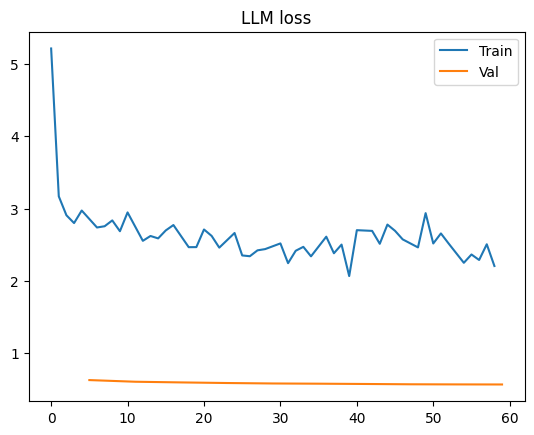

In [81]:
import matplotlib.pyplot as plt
trainloss = trainHistoryDF[~trainHistoryDF["loss"].isnull()]
valloss = trainHistoryDF[~trainHistoryDF["eval_loss"].isnull()]
plt.plot(trainloss["loss"], label="Train")
plt.plot(valloss["eval_loss"], label="Val")
plt.title("LLM loss")
plt.legend()
plt.show()

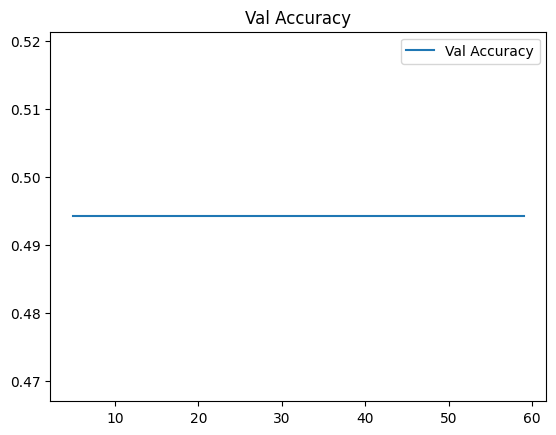

In [82]:
trainloss = trainHistoryDF[~trainHistoryDF["eval_accuracy"].isnull()]
plt.plot(trainloss["eval_accuracy"], label="Val Accuracy")
plt.title("Val Accuracy")
plt.legend()
plt.show()

In [83]:
# Zip for SFT only
import shutil
shutil.make_archive("/kaggle/working/submission", "zip", SFT_ADAPTER)

print("Done — submission.zip ready")

Done — submission.zip ready


In [84]:
clearMemory()

In [85]:
RUN_FINIAL_EVAL = False

In [86]:
# === Final Evaluation ===
print("Running final evaluation on SFT model...")



if RUN_FINIAL_EVAL:
    del model
    del tokenizer
    model, tokenizer = load_model(BASE_MODEL_PATH, SFT_ADAPTER)
    evaluate_model(
        model,
        tokenizer,
        val_size=10
    )

mlflow.end_run()

Running final evaluation on SFT model...


In [87]:
# if RUN_FINIAL_EVAL:
#     loraEvalRet = mlflow.search_runs(search_all_experiments=True)
#     loraEvalRet

In [88]:
loraEvalRet = mlflow.search_runs(search_all_experiments=True)
loraEvalRet

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.loss,metrics.train_loss,metrics.eval_runtime,metrics.eval_loss,...,params.adam_beta1,params.disable_tqdm,params.do_train,params.optim,params.routed_scaling_factor,params.bf16_full_eval,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
0,c0dea8c3b8d34365bbd2f57ef45ed016,1,FINISHED,/kaggle/working/mlruns/1/c0dea8c3b8d34365bbd2f...,2026-05-31 13:04:37.693000+00:00,2026-05-31 15:51:00.203000+00:00,2.205517,2.627674,50.2545,0.568111,...,0.9,False,False,adamw_torch_fused,2.5,False,root,__notebook_source__.ipynb,eval_sft_training,NOTEBOOK
1,29fcab7820ef4186a9b5eea2f90513d3,1,FINISHED,/kaggle/working/mlruns/1/29fcab7820ef4186a9b5e...,2026-05-31 13:03:36.216000+00:00,2026-05-31 13:04:37.685000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,root,__notebook_source__.ipynb,eval_sft_training,NOTEBOOK
2,93b8de07c3ef49398e65678e50edf031,1,FINISHED,/kaggle/working/mlruns/1/93b8de07c3ef49398e656...,2026-05-31 13:02:43.879000+00:00,2026-05-31 13:03:36.207000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,root,__notebook_source__.ipynb,eval_sft_training,NOTEBOOK


## Reinforcement Learning

In [89]:
clearMemory()

In [90]:
# === SAME STABLE PROMPT FORMAT AS SFT ===
def format_grpo_example(row):
    prompt = row['prompt']
    answer = str(row['answer']).strip()
    chat_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
<|user|>{prompt}
<|assistant|>"""
    return {"prompt": chat_prompt, "ground_truth": answer}

In [91]:
# === REWARD FUNCTION ===
def grpo_reward_function(prompts, completions, ground_truths, **kwargs):
    rewards = []
    for completion, gt in zip(completions, ground_truths):
        pred = completion.split("<|assistant|>")[-1].strip() if "<|assistant|>" in completion else completion.strip()
        for token in ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]:
            pred = pred.replace(token, "").strip()
        rewards.append(1.0 if pred.lower().strip() == str(gt).lower().strip() else 0.0)
    return rewards

In [92]:
del dataset
torch.cuda.empty_cache()
import gc
gc.collect()

0

In [93]:
rfdataset = Dataset.from_pandas(trainDF).map(format_grpo_example, remove_columns=trainDF.columns.tolist())
rfdataset

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'ground_truth'],
    num_rows: 9500
})

In [94]:
print(f"✅ GRPO dataset size: {len(rfdataset)} examples")

✅ GRPO dataset size: 9500 examples


In [ ]:
# del model
# del tokenizer

In [ ]:
clearMemory()

In [ ]:
 # model, tokenizer = load_model(BASE_MODEL_PATH, SFT_ADAPTER)

In [ ]:
# model = get_peft_model(model, lora_config)

In [ ]:
# model.print_trainable_parameters()

In [ ]:
# === GRPO Training Arguments ===
# run = setup_mlflow_run(EXPERIMENT_NAME, "grpo_training")
# mlflow.log_params({
#     "max_lora_rank": 16,
#     "max_tokens": 7680,
#     "max_model_len": 8192,
#     "temperature": 0.0,
#     "top_p": 1.0,
# })


In [ ]:

# grpo_config = GRPOConfig(
#     output_dir=OUTPUT_ADAPTER,
#     per_device_train_batch_size=1,
#     gradient_accumulation_steps=4,
#     learning_rate=5e-6,
#     num_train_epochs=1,
#     num_generations=4,           # reduced for memory
#     beta=0.04,
#     temperature=0.0,
#     top_p=1.0,
#     logging_steps=20,
#     save_strategy="no",          # avoid disk full
#     bf16=True,
#     gradient_checkpointing=False,
#     # packing=False,
# )

In [ ]:
# trainer = GRPOTrainer(
#     model=model,
#     args=grpo_config,
#     train_dataset=rfdataset,
#     processing_class=tokenizer,
#     reward_funcs=grpo_reward_function,
# )